# Notebook 03

# Explainability Analysis of the Hybrid BERT–XGBoost Spam Detection Model Using SHAP

---

## Objective

This notebook provides explainability analysis for the proposed Hybrid BERT–XGBoost email spam and phishing detection framework.

Unlike the previous notebook, which explained the predictions of the fine-tuned BERT classifier using Local Interpretable Model-Agnostic Explanations (LIME), this notebook explains the predictions generated by the hybrid architecture.

The hybrid model combines semantic feature extraction from a fine-tuned BERT transformer with classification using Extreme Gradient Boosting (XGBoost). Email representations are obtained from the contextualised `[CLS]` embedding produced by the transformer, while the XGBoost classifier performs the final prediction.

To interpret the contribution of each embedding dimension to the prediction, SHapley Additive exPlanations (SHAP) are employed. SHAP provides both local explanations for individual predictions and global explanations describing overall feature importance across the evaluation dataset.

The notebook performs the following tasks:

- Load the fine-tuned BERT model.
- Load the trained XGBoost classifier.
- Extract contextualised `[CLS]` embeddings.
- Generate predictions using the hybrid model.
- Select representative correctly classified emails.
- Generate SHAP explanations.
- Produce local and global feature importance visualisations.
- Save figures and reports for dissertation documentation.

In [5]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import random
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import torch
from transformers import AutoTokenizer, AutoModel

import xgboost as xgb

import shap

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

print("=" * 70)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 70)

LIBRARIES IMPORTED SUCCESSFULLY


In [6]:
# ==========================================================
# PROJECT CONFIGURATION
# ==========================================================

PROJECT_ROOT = Path.cwd().parent

MODELS = PROJECT_ROOT / "models"
DATASETS = PROJECT_ROOT / "datasets"
FIGURES = PROJECT_ROOT / "figures"
REPORTS = PROJECT_ROOT / "reports"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

FIGURES.mkdir(exist_ok=True)
REPORTS.mkdir(exist_ok=True)

print("=" * 70)
print("PROJECT CONFIGURATION")
print("=" * 70)

print(f"Device : {DEVICE}")
print(f"Project : {PROJECT_ROOT}")

PROJECT CONFIGURATION
Device : cpu
Project : C:\Users\DELL\Documents\Email_Phishing_Project\notebooks


In [9]:
# ==========================================================
# PROJECT CONFIGURATION
# ==========================================================

from pathlib import Path
import random
import numpy as np
import torch

# Notebook location:
# Email_Phishing_Project/notebooks/student4

PROJECT_ROOT = Path.cwd().parents[1]

MODELS = PROJECT_ROOT / "models"
DATASETS = PROJECT_ROOT / "datasets"
FIGURES = PROJECT_ROOT / "figures"
REPORTS = PROJECT_ROOT / "reports"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

FIGURES.mkdir(exist_ok=True)
REPORTS.mkdir(exist_ok=True)

print("=" * 70)
print("PROJECT CONFIGURATION")
print("=" * 70)

print("Current Working Directory :", Path.cwd())
print("Project Root              :", PROJECT_ROOT)
print("Models Folder Exists      :", MODELS.exists())
print("Datasets Folder Exists    :", DATASETS.exists())
print("Figures Folder Exists     :", FIGURES.exists())
print("Reports Folder Exists     :", REPORTS.exists())

PROJECT CONFIGURATION
Current Working Directory : C:\Users\DELL\Documents\Email_Phishing_Project\notebooks\student4
Project Root              : C:\Users\DELL\Documents\Email_Phishing_Project
Models Folder Exists      : True
Datasets Folder Exists    : True
Figures Folder Exists     : True
Reports Folder Exists     : True


In [10]:
# ==========================================================
# LOAD TRAINED XGBOOST MODEL
# ==========================================================

print("=" * 70)
print("LOADING XGBOOST MODEL")
print("=" * 70)

xgb_model = joblib.load(
    MODELS / "best_bert_xgboost.pkl"
)

print("✓ XGBoost model loaded successfully.")
print(type(xgb_model))

LOADING XGBOOST MODEL
✓ XGBoost model loaded successfully.
<class 'xgboost.sklearn.XGBClassifier'>


In [8]:
print(Path.cwd())
print(PROJECT_ROOT)

C:\Users\DELL\Documents\Email_Phishing_Project\notebooks\student4
C:\Users\DELL\Documents\Email_Phishing_Project\notebooks


In [11]:
# ==========================================================
# VERIFY LOADED MODELS
# ==========================================================

print("=" * 70)
print("MODEL VERIFICATION")
print("=" * 70)

print(f"BERT Model      : {MODEL_NAME}")
print(f"Device          : {DEVICE}")
print(f"Training Mode   : {bert_model.training}")

print(f"\nHybrid Classifier : {type(xgb_model).__name__}")

if hasattr(xgb_model, "classes_"):
    print(f"Classes           : {xgb_model.classes_}")

if hasattr(xgb_model, "n_features_in_"):
    print(f"Input Features    : {xgb_model.n_features_in_}")

MODEL VERIFICATION
BERT Model      : bert-base-uncased
Device          : cpu
Training Mode   : False

Hybrid Classifier : XGBClassifier
Classes           : [0 1]
Input Features    : 768


In [12]:
# ==========================================================
# LOAD EVALUATION DATASET
# ==========================================================

print("=" * 70)
print("LOADING EVALUATION DATASET")
print("=" * 70)

test_df = pd.read_csv(
    DATASETS / "processed" / "bert_test_subset.csv"
)

print(f"Dataset Shape : {test_df.shape}")

print("\nColumns")
print(test_df.columns.tolist())

print("\nLabel Distribution")
print(test_df["label"].value_counts())

test_df.head()

LOADING EVALUATION DATASET
Dataset Shape : (1000, 7)

Columns
['dataset', 'subject', 'body', 'email_text', 'label', 'cleaned_email_text', 'email_length']

Label Distribution
label
0    910
1     90
Name: count, dtype: int64


,dataset,subject,body,email_text,label,cleaned_email_text,email_length
0,CEAS,Re: [opensuse] Defragging: possible? necessary?,-----BEGIN PGP SIGNED MESSAGE-----\nHash: SHA1...,Re: [opensuse] Defragging: possible? necessar...,0,Re: [opensuse] Defragging: possible? necessary...,1215
1,Enron,Re:,michaelpshannon@yahoo.com,Re: michaelpshannon@yahoo.com,0,Re: michaelpshannon@yahoo.com,29
2,Enron,Executing Broker Agreement for CSFB,"Cheryl, Donna, Cassandra and Bill,\n\nI am for...","Executing Broker Agreement for CSFB Cheryl, Do...",0,"Executing Broker Agreement for CSFB Cheryl, Do...",241
3,Enron,FW: Follow-up on CA energy crisis info.,\nVince:\n\nCan you let me know the answer to ...,FW: Follow-up on CA energy crisis info. \nVinc...,0,FW: Follow-up on CA energy crisis info. Vince:...,408
4,Enron,BASE CONTRACT FOR SHORT-TERM,\n\n******************************************...,BASE CONTRACT FOR SHORT-TERM \n\n*************...,0,BASE CONTRACT FOR SHORT-TERM *****************...,418


In [13]:
# ==========================================================
# EXTRACT CLS EMBEDDINGS
# ==========================================================

MAX_LENGTH = 256

def extract_cls_embeddings(texts, batch_size=32):

    embeddings = []

    bert_model.eval()

    with torch.no_grad():

        for start in tqdm(
            range(0, len(texts), batch_size),
            desc="Extracting CLS Embeddings"
        ):

            batch = texts[start:start+batch_size]

            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors="pt"
            )

            encoded = {
                k: v.to(DEVICE)
                for k, v in encoded.items()
            }

            outputs = bert_model(**encoded)

            cls_vectors = outputs.last_hidden_state[:, 0, :]

            embeddings.append(
                cls_vectors.cpu().numpy()
            )

    return np.vstack(embeddings)

In [14]:
# ==========================================================
# GENERATE CLS EMBEDDINGS
# ==========================================================

email_texts = (
    test_df["cleaned_email_text"]
    .fillna("")
    .tolist()
)

X_embeddings = extract_cls_embeddings(
    email_texts,
    batch_size=64
)

print("=" * 70)
print("EMBEDDING MATRIX")
print("=" * 70)

print(X_embeddings.shape)

Extracting CLS Embeddings:   0%|          | 0/16 [00:00<?, ?it/s]

EMBEDDING MATRIX
(1000, 768)


In [15]:
# ==========================================================
# GENERATE HYBRID MODEL PREDICTIONS
# ==========================================================

print("=" * 70)
print("GENERATING HYBRID MODEL PREDICTIONS")
print("=" * 70)

predicted_labels = xgb_model.predict(X_embeddings)

prediction_probabilities = xgb_model.predict_proba(X_embeddings)

test_df["predicted_label"] = predicted_labels

test_df["ham_probability"] = prediction_probabilities[:, 0]

test_df["spam_probability"] = prediction_probabilities[:, 1]

test_df["correct_prediction"] = (
    test_df["label"] == test_df["predicted_label"]
)

accuracy = test_df["correct_prediction"].mean()

print(f"Accuracy : {accuracy:.4f}")

print("\nPrediction Distribution")

print(test_df["predicted_label"].value_counts())

GENERATING HYBRID MODEL PREDICTIONS
Accuracy : 0.5190

Prediction Distribution
predicted_label
1    531
0    469
Name: count, dtype: int64


In [16]:
# ==========================================================
# HYBRID MODEL EVALUATION
# ==========================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("HYBRID MODEL PERFORMANCE")
print("=" * 70)

print(classification_report(
    test_df["label"],
    test_df["predicted_label"],
    digits=4
))

cm = confusion_matrix(
    test_df["label"],
    test_df["predicted_label"]
)

print("\nConfusion Matrix")

print(cm)

HYBRID MODEL PERFORMANCE
              precision    recall  f1-score   support

           0     0.9574    0.4934    0.6512       910
           1     0.1318    0.7778    0.2254        90

    accuracy                         0.5190      1000
   macro avg     0.5446    0.6356    0.4383      1000
weighted avg     0.8831    0.5190    0.6129      1000


Confusion Matrix
[[449 461]
 [ 20  70]]


In [17]:
# ==========================================================
# SELECT REPRESENTATIVE EMAILS
# ==========================================================

correct_predictions = test_df[
    test_df["correct_prediction"]
].copy()

correct_spam = (
    correct_predictions[
        correct_predictions["label"] == 1
    ]
    .sort_values(
        "spam_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

correct_ham = (
    correct_predictions[
        correct_predictions["label"] == 0
    ]
    .sort_values(
        "ham_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

spam_case_1 = correct_spam.iloc[0]
spam_case_2 = correct_spam.iloc[1]

ham_case_1 = correct_ham.iloc[0]
ham_case_2 = correct_ham.iloc[1]

print("=" * 70)
print("REPRESENTATIVE EMAILS SELECTED")
print("=" * 70)

print(f"Correct Spam Emails : {len(correct_spam)}")
print(f"Correct Ham Emails  : {len(correct_ham)}")

print("\nSpam Case 1")
print(spam_case_1["spam_probability"])

print("\nSpam Case 2")
print(spam_case_2["spam_probability"])

print("\nHam Case 1")
print(ham_case_1["ham_probability"])

print("\nHam Case 2")
print(ham_case_2["ham_probability"])

REPRESENTATIVE EMAILS SELECTED
Correct Spam Emails : 70
Correct Ham Emails  : 449

Spam Case 1
0.97451425

Spam Case 2
0.95442367

Ham Case 1
0.96880424

Ham Case 2
0.9623807


In [18]:
# ==========================================================
# INITIALIZE SHAP EXPLAINER
# ==========================================================

print("=" * 70)
print("INITIALIZING SHAP EXPLAINER")
print("=" * 70)

explainer = shap.TreeExplainer(xgb_model)

print("✓ SHAP TreeExplainer initialized successfully.")

INITIALIZING SHAP EXPLAINER
✓ SHAP TreeExplainer initialized successfully.


In [19]:
# ==========================================================
# COMPUTE SHAP VALUES
# ==========================================================

print("=" * 70)
print("COMPUTING SHAP VALUES")
print("=" * 70)

shap_values = explainer.shap_values(X_embeddings)

print("SHAP values computed successfully.")

if isinstance(shap_values, list):
    print(f"Classes: {len(shap_values)}")
    print(f"Shape : {shap_values[1].shape}")
else:
    print(f"Shape : {shap_values.shape}")

COMPUTING SHAP VALUES
SHAP values computed successfully.
Shape : (1000, 768)


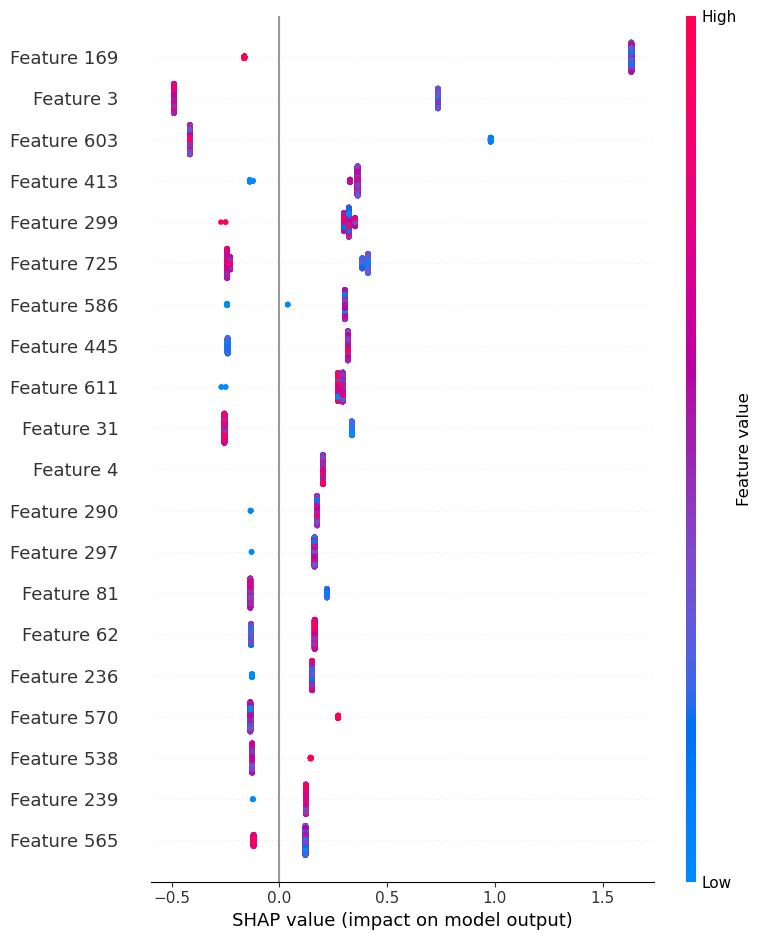

✓ Summary plot saved.


In [20]:
# ==========================================================
# GLOBAL SHAP SUMMARY
# ==========================================================

plt.figure(figsize=(12,8))

if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_embeddings,
        show=False
    )
else:
    shap.summary_plot(
        shap_values,
        X_embeddings,
        show=False
    )

plt.tight_layout()

plt.savefig(
    FIGURES / "bert_xgboost_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Summary plot saved.")

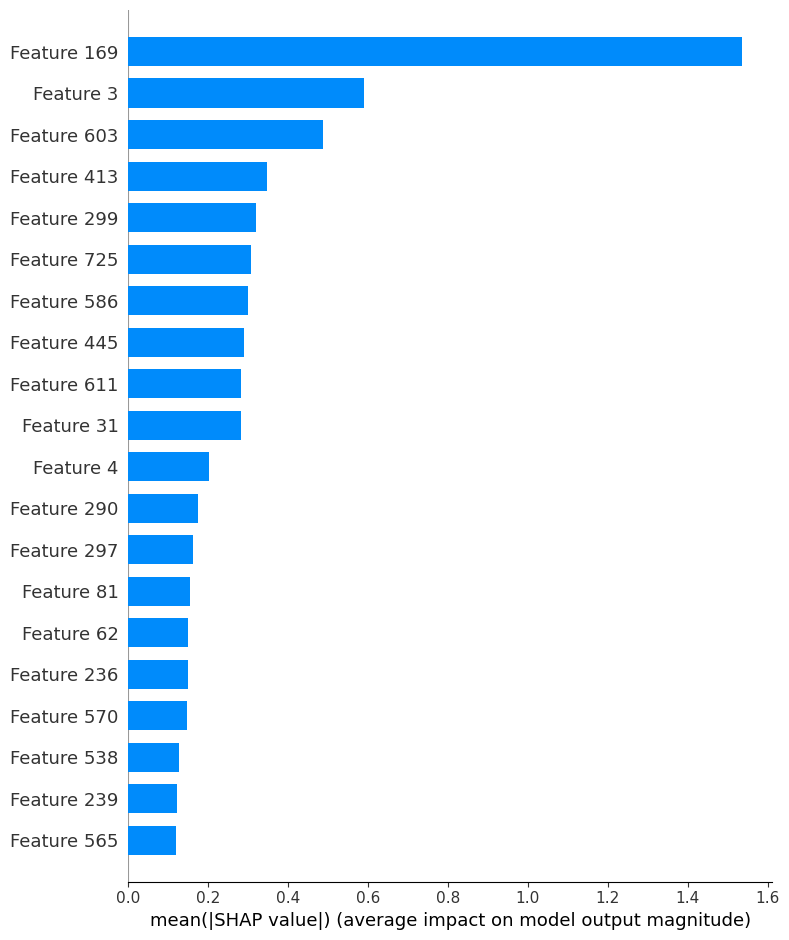

✓ Feature importance plot saved.


In [21]:
# ==========================================================
# GLOBAL FEATURE IMPORTANCE
# ==========================================================

plt.figure(figsize=(10,8))

if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_embeddings,
        plot_type="bar",
        show=False
    )
else:
    shap.summary_plot(
        shap_values,
        X_embeddings,
        plot_type="bar",
        show=False
    )

plt.tight_layout()

plt.savefig(
    FIGURES / "bert_xgboost_shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Feature importance plot saved.")

In [22]:
# ==========================================================
# GENERATE LOCAL SHAP EXPLANATION
# ==========================================================

def generate_local_shap(index, case_name):

    print("=" * 70)
    print(f"Generating SHAP explanation: {case_name}")
    print("=" * 70)

    plt.figure(figsize=(10,6))

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[index],
            base_values=explainer.expected_value,
            data=X_embeddings[index],
            feature_names=[
                f"Embedding_{i}"
                for i in range(X_embeddings.shape[1])
            ]
        ),
        max_display=15,
        show=False
    )

    plt.tight_layout()

    figure_path = FIGURES / f"{case_name}.png"

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    feature_df = pd.DataFrame({
        "Feature":[
            f"Embedding_{i}"
            for i in range(X_embeddings.shape[1])
        ],
        "SHAP_Value":shap_values[index],
        "Embedding_Value":X_embeddings[index]
    })

    feature_df = feature_df.reindex(
        feature_df.SHAP_Value.abs()
        .sort_values(ascending=False).index
    )

    feature_df.to_csv(
        REPORTS / f"{case_name}.csv",
        index=False
    )

    print("✓ Figure saved.")
    print("✓ CSV saved.")

    return feature_df

In [23]:
spam_index_1 = spam_case_1.name
spam_index_2 = spam_case_2.name

ham_index_1 = ham_case_1.name
ham_index_2 = ham_case_2.name

print(spam_index_1, spam_index_2)
print(ham_index_1, ham_index_2)

0 1
0 1


In [24]:
bert_spam_shap_1 = generate_local_shap(
    spam_index_1,
    "bert_xgboost_shap_spam_case1"
)

bert_spam_shap_2 = generate_local_shap(
    spam_index_2,
    "bert_xgboost_shap_spam_case2"
)

bert_ham_shap_1 = generate_local_shap(
    ham_index_1,
    "bert_xgboost_shap_ham_case1"
)

bert_ham_shap_2 = generate_local_shap(
    ham_index_2,
    "bert_xgboost_shap_ham_case2"
)

Generating SHAP explanation: bert_xgboost_shap_spam_case1
✓ Figure saved.
✓ CSV saved.
Generating SHAP explanation: bert_xgboost_shap_spam_case2
✓ Figure saved.
✓ CSV saved.
Generating SHAP explanation: bert_xgboost_shap_ham_case1
✓ Figure saved.
✓ CSV saved.
Generating SHAP explanation: bert_xgboost_shap_ham_case2
✓ Figure saved.
✓ CSV saved.


In [25]:
summary = pd.DataFrame({
    "Case":[
        "Spam Case 1",
        "Spam Case 2",
        "Ham Case 1",
        "Ham Case 2"
    ],
    "Confidence":[
        spam_case_1["spam_probability"],
        spam_case_2["spam_probability"],
        ham_case_1["ham_probability"],
        ham_case_2["ham_probability"]
    ]
})

summary = summary.round(6)

display(summary)

summary.to_csv(
    REPORTS / "bert_xgboost_shap_summary.csv",
    index=False
)

print("✓ Summary saved successfully.")

,Case,Confidence
0,Spam Case 1,0.974514
1,Spam Case 2,0.954424
2,Ham Case 1,0.968804
3,Ham Case 2,0.962381


✓ Summary saved successfully.
